# Deep Learning with Keras: LSTM & CNN

### Neural Networks for Time Series Forecasting and Image Classification

This project explores two different deep learning architectures using **TensorFlow and Keras**:

1. A **Long Short-Term Memory (LSTM)** neural network for time series forecasting.
2. A **Convolutional Neural Network (CNN)** for image classification using the CIFAR-10 dataset.

The objective is to demonstrate how different neural network architectures can be adapted to different data structures: sequential data for the LSTM and spatial image data for the CNN.

## 1. LSTM for Time Series Forecasting

Long Short-Term Memory (LSTM) networks are recurrent neural networks specifically designed to capture temporal dependencies in sequential data.

In this experiment, an LSTM model is trained to predict the next value of a synthetic time series based on a sequence of previous observations.

The workflow includes:

- Synthetic time series generation
- Data normalization
- Train/test splitting
- Sliding-window sequence generation
- LSTM model construction
- Model training and validation
- Evaluation on unseen data
- Comparison between predicted and actual values

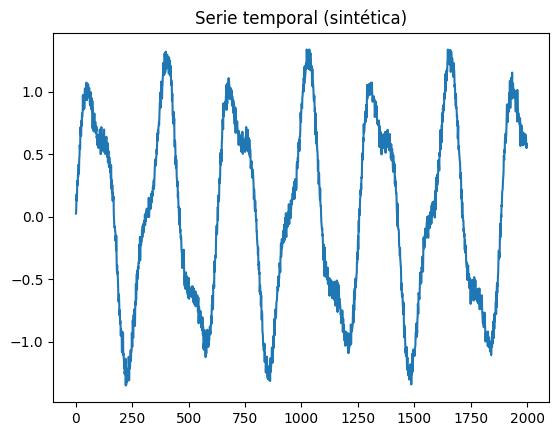

In [ ]:
# Imports and reproducibility

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)
tf.random.set_seed(42)

# Generate synthetic time series: sine waves + random noise
N = 2000
t = np.arange(N)
serie = np.sin(0.02 * t) + 0.3*np.sin(0.05*t) + 0.05*np.random.randn(N)

plt.figure()
plt.plot(serie)
plt.title("Synthetic Time Series")
plt.show()


### 1.1 Data Preprocessing

The generated time series is normalized using **Min-Max scaling**, transforming the values into a common numerical range before training the neural network.

The normalized sequence is then divided chronologically:

- **80%** for training
- **20%** for testing

A chronological split is used because preserving temporal order is essential when working with time series data.

In [ ]:
# Normalize and split the dataset

serie = serie.reshape(-1, 1)

train_size = int(len(serie) * 0.8)
train_raw, test_raw = serie[:train_size], serie[train_size:]

scaler = MinMaxScaler()
train = scaler.fit_transform(train_raw)
test = scaler.transform(test_raw)

train.shape, test.shape


### 1.2 Sequence Generation

LSTM networks require sequential input rather than isolated observations.

A **sliding-window approach** is therefore used to transform the original time series into supervised learning samples.

With a lookback window of **30 observations**, each training sample contains:

- The previous 30 time steps as input.
- The following value as the prediction target.

The resulting input tensor follows the standard LSTM structure:

`(samples, time steps, features)`

In [ ]:
# Create sliding-window sequences and reshape data

def create_sequences(data, lookback=30):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

lookback = 30
X_train, y_train = create_sequences(train, lookback)
X_test, y_test   = create_sequences(test, lookback)

# X already follows the shape: (samples, time steps, features=1)
X_train.shape, y_train.shape, X_test.shape, y_test.shape


### 1.3 LSTM Architecture

A compact Sequential neural network is constructed using Keras.

The architecture consists of:

- An input layer receiving sequences of **30 time steps** with one feature per step.
- An **LSTM layer with 64 units** responsible for learning temporal patterns.
- A fully connected **Dense output layer with one neuron** for predicting the next value of the sequence.

This architecture represents a sequence-to-one forecasting problem.

In [ ]:
# 4) LSTM model architecture (Sequential)

model = keras.Sequential([
    layers.Input(shape=(lookback, 1)),
    layers.LSTM(64),
    layers.Dense(1)
])

model.summary()


### 1.4 Model Compilation

The model is trained using the **Adam optimizer** and **Mean Squared Error (MSE)** as the loss function.

MSE is appropriate for this regression problem because it penalizes larger prediction errors more strongly.

In [ ]:
# 5) Model compilation

model.compile(optimizer="adam", loss="mse")


### 1.5 Model Training

The LSTM is trained for **20 epochs** using a batch size of **32**.

A 20% validation split is extracted from the training data to monitor the model's behavior on observations not directly used for parameter optimization.

In [ ]:
# Model training with validation

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)


### 1.6 Model Evaluation

The trained model is evaluated on the held-out test set using Mean Squared Error.

Training and validation losses are compared across epochs to analyze convergence and detect potential overfitting.

Finally, predictions are transformed back to the original scale and compared visually with the real test sequence.

In [ ]:
# 7) Evaluate on the test set

test_loss = model.evaluate(X_test, y_test, verbose=0)
print("Test MSE:", test_loss)

# Training and validation loss
plt.figure()
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Generate Predictions
y_pred = model.predict(X_test)

y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

plt.figure()
plt.plot(y_test_inv, label="Actual")
plt.plot(y_pred_inv, label="Predicted")
plt.title("Actual vs Predicted Values (test-set)")
plt.xlabel("Samples")
plt.ylabel("Value")
plt.legend()
plt.show()


### 1.7 Results

The LSTM successfully learns the underlying temporal structure of the synthetic signal.

The training and validation loss curves allow the convergence of the model to be monitored throughout training, while evaluation on the test set measures its ability to generalize to unseen observations.

The comparison between actual and predicted values provides a direct visualization of the forecasting capability of the network.

This experiment demonstrates the complete workflow required to transform a raw time series into sequential samples suitable for an LSTM neural network and use them to perform one-step-ahead forecasting.

## 2. CNN for Image Classification

Convolutional Neural Networks (CNNs) are specifically designed to process image data by learning spatial patterns such as edges, textures and increasingly complex visual features.

In this experiment, a CNN is trained to classify images from the **CIFAR-10** dataset into 10 different categories.

The workflow includes:

- CIFAR-10 dataset loading
- Image normalization
- One-hot encoding of class labels
- Data augmentation
- Convolutional feature extraction
- Regularization with Dropout and L2
- Model training with Early Stopping
- Model evaluation on unseen test images
- Training and validation curve analysis

In [ ]:
# Imports and CIFAR-10 dataset loading

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train.shape, y_train.shape, x_test.shape, y_test.shape


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

### 2.1 Data Preprocessing

The CIFAR-10 dataset contains RGB images of size **32 × 32 pixels** distributed across 10 classes.

Pixel values are normalized from the original range `[0, 255]` to `[0, 1]` to improve numerical stability during neural network training.

The class labels are converted into one-hot encoded vectors because the model performs multi-class classification using categorical cross-entropy.

A small sample of training images is also visualized to inspect the dataset and its class labels.

/tmp/ipython-input-4083257996.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


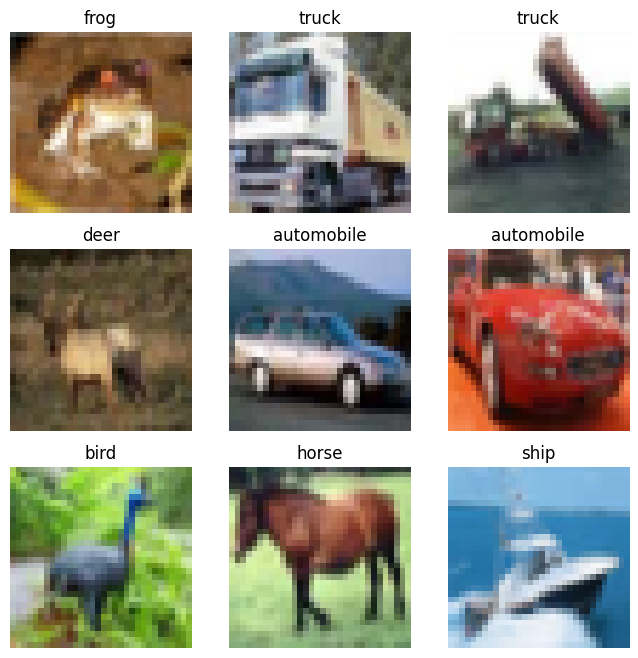

In [ ]:
# Normalize images and encode labels

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

y_train_oh = to_categorical(y_train, 10)
y_test_oh  = to_categorical(y_test, 10)

y_train_oh.shape, y_test_oh.shape

# Display sample training images
class_names = [
     "airplane", "automobile", "bird", "cat",
     "deer", "dog", "frog", "horse", "ship", "truck"
     ]

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i][0])])
    plt.axis("off")
plt.show()


### 2.2 Data Augmentation and Regularization

To improve generalization and reduce overfitting, several regularization techniques are applied.

The training images are randomly transformed using:

- Horizontal flipping
- Small translations
- Small rotations

These transformations generate slightly different versions of the original images during training, helping the model become more robust to variations in image orientation and position.

Additionally, **L2 regularization** and **Dropout** are applied throughout the network to reduce excessive dependence on individual parameters and improve generalization.

### 2.3 CNN Architecture

The convolutional network is composed of three feature-extraction blocks with an increasing number of filters:

- 32 convolutional filters
- 64 convolutional filters
- 128 convolutional filters

Each convolutional layer uses a **3 × 3 kernel**, ReLU activation and same padding, followed by Max Pooling and Dropout.

The extracted feature maps are then flattened and processed by a fully connected layer with 128 neurons.

The final layer contains **10 neurons with Softmax activation**, producing a probability distribution over the 10 CIFAR-10 classes.

In [ ]:
# 3) Data augmentation and CNN Architecture

from tensorflow import keras
from tensorflow.keras import layers, regularizers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomRotation(0.1),
])

l2 = regularizers.l2(1e-4)

inputs = keras.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)

x = layers.Conv2D(32, (3,3), activation="relu", padding="same", kernel_regularizer=l2)(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(64, (3,3), activation="relu", padding="same", kernel_regularizer=l2)(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(128, (3,3), activation="relu", padding="same", kernel_regularizer=l2)(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.25)(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu", kernel_regularizer=l2)(x)
x = layers.Dropout(0.5)(x)

# Output probabilities for the 10 classes
outputs = layers.Dense(10, activation="softmax", dtype="float32")(x)

model = keras.Model(inputs, outputs)
model.summary()




Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

### 2.4 Model Compilation

The CNN is compiled using the **Adam optimizer** and **categorical cross-entropy** as the loss function.

Categorical cross-entropy is suitable for this problem because each image belongs to exactly one of the 10 possible classes.

Classification accuracy is used as the main evaluation metric during training.

In [ ]:
# 4) Model Compilation

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])



### 2.5 Model Training

The model is trained for a maximum of **30 epochs** using a batch size of **128**.

A 20% validation split is used to monitor performance on data not directly used for weight optimization.

Two callbacks are included:

- **Early Stopping**, which stops training when validation loss stops improving.
- **Model Checkpoint**, which stores the model with the best validation loss.

Early Stopping uses a patience of three epochs and restores the best model weights after training.

In [ ]:
# 5) Training callbacks

early = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

ckpt = keras.callbacks.ModelCheckpoint(
    "best_cifar.keras",
    monitor="val_loss",
    save_best_only=True
)

# Model training

history = model.fit(
    x_train, y_train_oh,
    validation_split=0.2,
    epochs=30,
    batch_size=128,
    callbacks=[early, ckpt],
    verbose=1
)




Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 67s 207ms/step - accuracy: 0.2122 - loss: 2.1282 - val_accuracy: 0.3999 - val_loss: 1.6957
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 209ms/step - accuracy: 0.3752 - loss: 1.7368 - val_accuracy: 0.4551 - val_loss: 1.5324
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 210ms/step - accuracy: 0.4217 - loss: 1.6285 - val_accuracy: 0.4943 - val_loss: 1.4399
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 209ms/step - accuracy: 0.4552 - loss: 1.5595 - val_accuracy: 0.5211 - val_loss: 1.4012
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 206ms/step - accuracy: 0.4747 - loss: 1.5149 - val_accuracy: 0.5658 - val_loss: 1.2860
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 212ms/step - accuracy: 0.4948 - loss: 1.4746 - val_accuracy: 0.5679 - val_loss: 1.2546
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 221ms/step - accuracy: 0.5000 - loss: 1.4504 - val_accuracy: 0.5794 - val_loss: 1.2521
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 219ms/step - accuracy: 0.5113 - loss: 1

### 2.6 Model Evaluation

The final model is evaluated on the CIFAR-10 test set, which was not used during training or validation.

Test loss and test accuracy provide an estimate of how well the network generalizes to previously unseen images.

In [ ]:
# 6) Evaluate on the test set

test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)


Test loss: 0.9972440600395203
Test accuracy: 0.6776999831199646


### 2.7 Training Analysis

Training and validation loss are compared across epochs to assess convergence and identify potential overfitting.

Accuracy curves are also analyzed to compare the model's performance on the training and validation subsets.

A small gap between training and validation performance generally indicates better generalization than a model whose training accuracy continues improving while validation performance deteriorates.

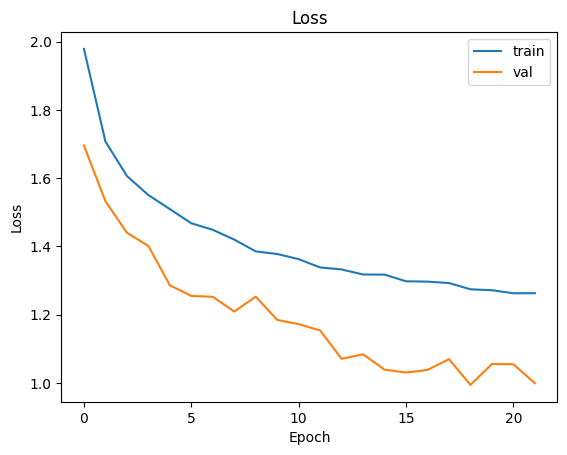

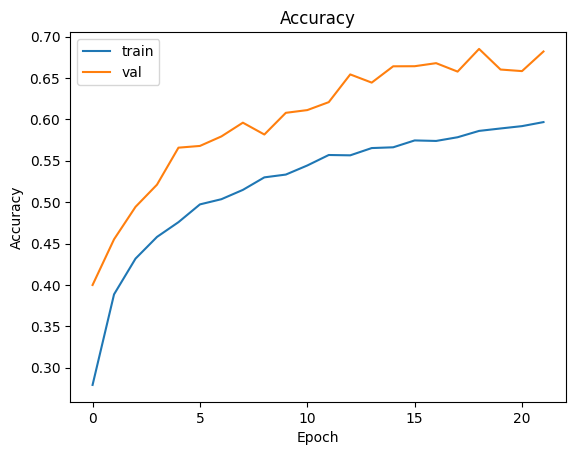

In [ ]:
# 7) Training and validation curves

plt.figure()
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


### 2.8 Results

A Convolutional Neural Network was developed for image classification on the CIFAR-10 dataset.

The architecture combines multiple convolutional blocks with ReLU activations and Max Pooling layers, followed by fully connected layers for final classification.

Several regularization techniques were incorporated, including:

- Data augmentation
- Dropout
- L2 regularization
- Early Stopping

These techniques were used to reduce overfitting and improve the model's ability to generalize to unseen images.

The model achieves a test accuracy of approximately **68%**, with a test loss close to **1.0**.

The training and validation curves remain relatively stable without strong divergence, suggesting that the selected architecture provides a reasonable balance between predictive performance and generalization.

Although simpler configurations achieved higher training accuracy during experimentation, they exhibited greater overfitting. The final architecture was therefore selected as a compromise between classification performance and model stability.

## 3. Conclusions

This project demonstrates two complementary deep learning workflows using TensorFlow and Keras.

The **LSTM experiment** illustrates how sequential neural networks can model temporal dependencies and perform one-step-ahead forecasting on time series data.

The **CNN experiment** demonstrates how convolutional architectures can extract spatial features from image data and perform multi-class classification.

Although both models are neural networks, their architectures are adapted to fundamentally different data structures:

- **LSTM:** sequential and temporal information
- **CNN:** spatial and visual information

The project also highlights several important deep learning practices, including data normalization, validation-based model selection, regularization, data augmentation, Dropout, Early Stopping and evaluation on held-out test data.

Together, both experiments provide a practical introduction to designing and evaluating neural networks for different machine learning domains.